# Summer School - Modeling Water Fluxes In The Soil-Plant System

## Simulating the growing root architecture and trait analysis

How to 

1. Simulate a root system 

2. Understanding model parameters 

3. Using confining containers or obstacles

4. Basic root system traits and their dynamics

5. Depth profiles

In [1]:
from IPython.display import SVG, display # to show svg files in the notebook

import vtk

import os
sourcedir = os.getcwd()+"/../../../"
import sys; sys.path.append(sourcedir); sys.path.append(sourcedir+"src")
import numpy as np
import matplotlib.pyplot as plt
import plantbox as pb 
import visualisation.vtk_plot as vp # for quick vizualisations

### 1. Simulate a root system

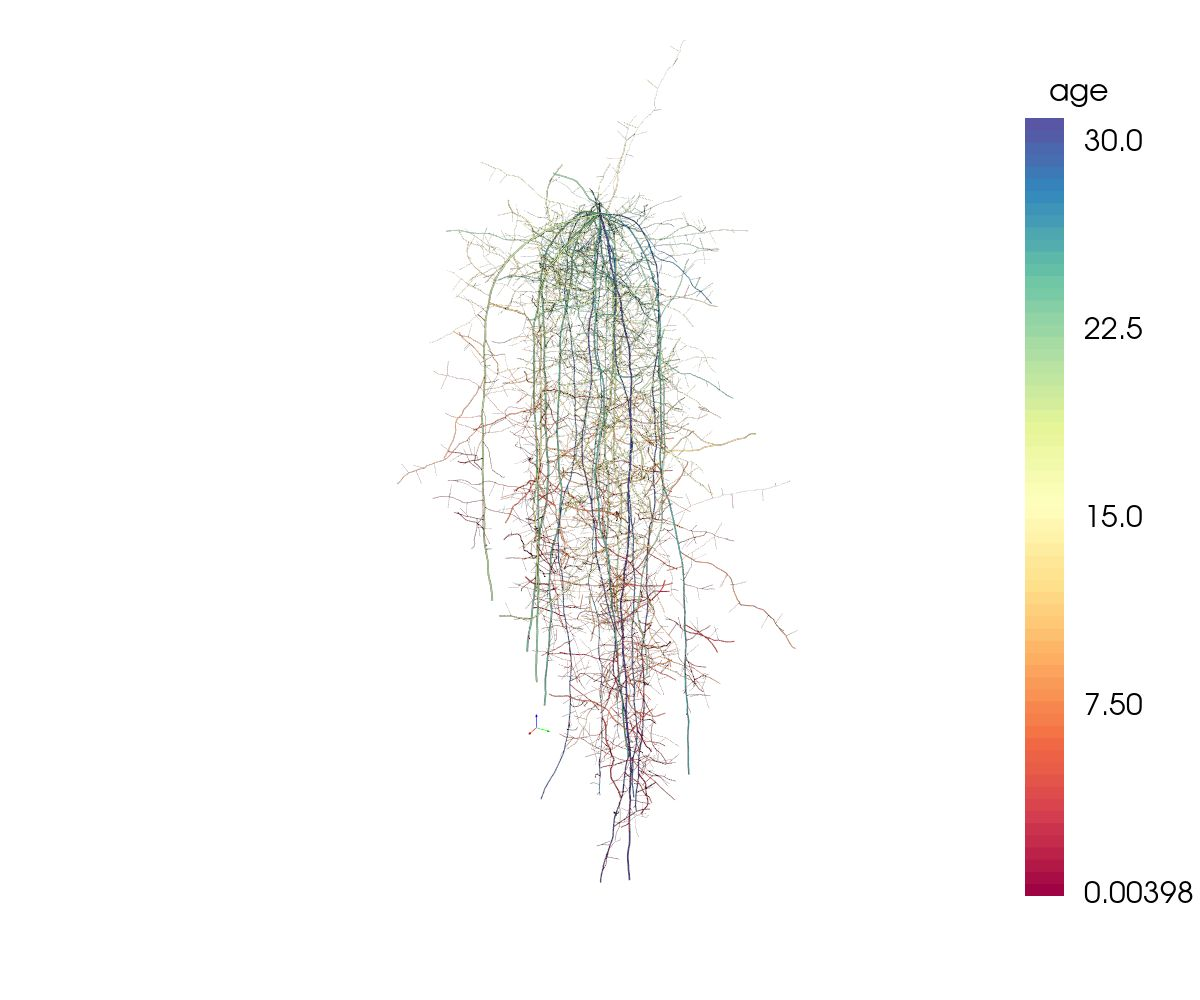

In [2]:
# Create instance describing a root system
rs = pb.Plant()

# Open plant and root parameter from a file
path = "../../../modelparameter/structural/rootsystem/"
name = "Zeamays_synMRI"
rs.readParameters(path + name + ".xml")

# Simulate
rs.initialize() 
rs.simulate(30) # [days]

# Export
rs.write("first_example.vtp") # for Paraview
rs.write("first_example.rsml") # e.g. gui/viewer/rsml_viewer.py

# Visualize
_ = vp.plot_plant(rs, "age", interactiveImage = False) # Plot, using vtk (e.g. "subType")

Multiple root systems are created in the very same way, see *example2a_initializeparams.py* (in CPlantBox/tutorial/examples/python/).

In this way a multitude of differently shaped root systems can be created. 

In [3]:
display(SVG(filename='figures/rootsystems.svg'))

### 2. Understanding model parameter

The seed contains the information to create the root system (and stem) and is defined by the class *SeedRandomParameter*. Each root type of emerging roots is represented by the class *RootRandomParameter*.

Specific plants and roots are presented by the classes *SeedSpecificParameter* and *RootSpecificParameter*. Instances of *SpecificParameter* classes are created (at organ creation) from the *RandomParameter* classes, usually by drawing specific random variables from a normal distribution, calling *RandomParameter::realize()*. 

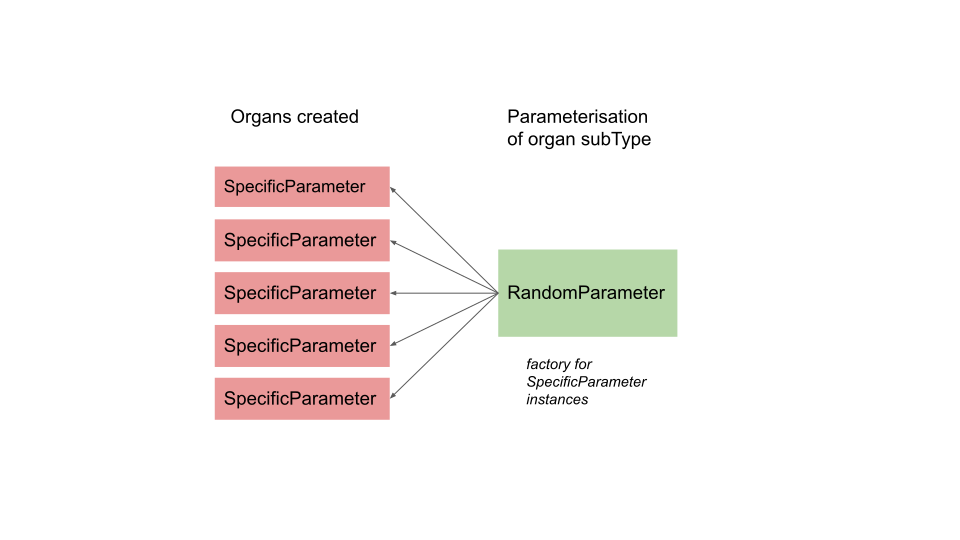

In [4]:
display(SVG(filename='figures/parameters.svg'))

This holds for all organs in CPlantBox: Seed, Root, Stem, and Leaf. In this summer school we focus on the roots. 

In [5]:
random_parameters = rs.getOrganRandomParameter(pb.root)
for p in random_parameters[1:]: # CPlantBox subTypes start at index 1
    print(p)

[Parameters of taproot]
Variable		Value		Deviation		Description
===
gf                	2		0			Growth function number [1]
organType         	2		-			Organ type (unspecified organ = 0, seed = 1, root = 2, stem = 3, leaf = 4)
subType           	1		-			Unique identifier of this sub type
tropismT          	1		-			Type of root tropism (plagio = 0, gravi = 1, exo = 2, hydro, chemo = 3)
a                 	0.0436		0.01			radius [cm]
dx                	0.2		-			Axial resolution [cm] (maximal segment size)
dxMin             	1e-06		-			Axial resolution [cm] (minimal segment size)
hairsElongation   	0		-			Zone behind the tip without root hairs  [cm]
hairsLength       	0		-			Root hair length [cm]
hairsZone         	0		-			Length of the root hair zone [cm]
la                	2.229		1.20834			Apical zone [cm]
lb                	1.37664		1.24005			Basal zone [cm]
ldelay            	6.15419		0.5			Lateral root emergence delay [day]
lmax              	150		0			Maximal root length [cm]
ln               

Most parameters are given by mean (parameter_name) and standard deviation (parameter_name+"s"). All random parameters can be accessed and changed (e.g. to reduce dx, or standard deviations)

Meaning of the variables of the *RootRandomParameter* class:

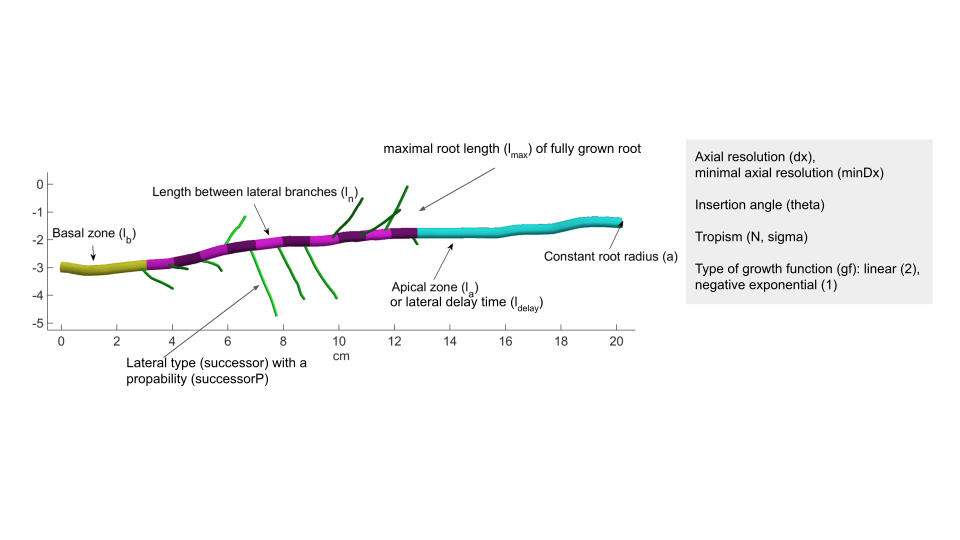

In [6]:
display(SVG(filename='figures/root_random_parameters.svg'))

The tropism parameters are given by the type of tropism (tropismT), N and sigma

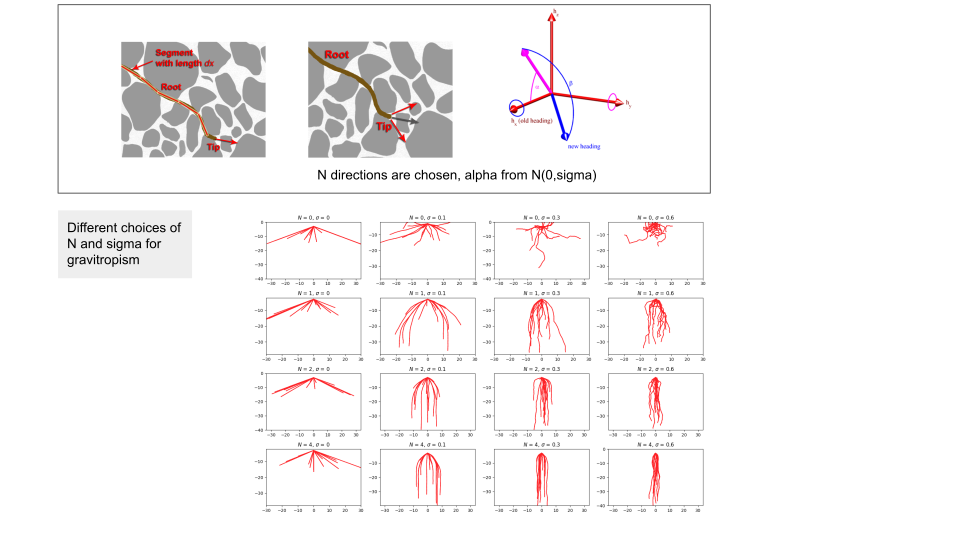

In [7]:
display(SVG(filename='figures/tropisms.svg'))

The example figure for gravitropism was created with the script *example2b_tropism.py* from the tutorial with an inertion angle of 70 degree (note that the figure will look different with another inserion angle). 

In [8]:
random_parameter = rs.getOrganRandomParameter(pb.seed)
print(type(random_parameter)) # it is eady to reveal the class type in Python
print()
print(random_parameter[0])

<class 'list'>

[Parameters of undefined]
Variable		Value		Deviation		Description
===
delayDefinition   	0		-			method implemented to evaluate root lateral growth delay (0: distance based, 1: delay based defined by parent organ)
delayDefinitionShoot	0		-			method implemented to evaluate shoot lateral growth delay (0: distance based, 1: delay based defined by parent organ)
maxTil            	0		0			Maximal number of tillers [1]
organType         	1		-			Organ type (unspecified organ = 0, seed = 1, root = 2, stem = 3, leaf = 4)
subType           	0		-			Unique identifier of this sub type
a                 	0.1		0			radius [cm]
delayB            	0.7866		0			Time delay between the basal roots [day]
delayRC           	1e+09		0			Delay between the root crowns [day]
delaySB           	1e+09		0			Time delay between the shoot borne roots [day]
delayTil          	1e+09		0			Time delay between the tillers [day]
dx                	0.25		-			Axial resolution [cm] (maximal segment size)
dxMin      

Most of above parameters are not important for dicots or young monocots (and some are ignored: a, dx, dxMin), some are for whole plants only (maxTi, firstTi).

For root systems the most important parameters are:

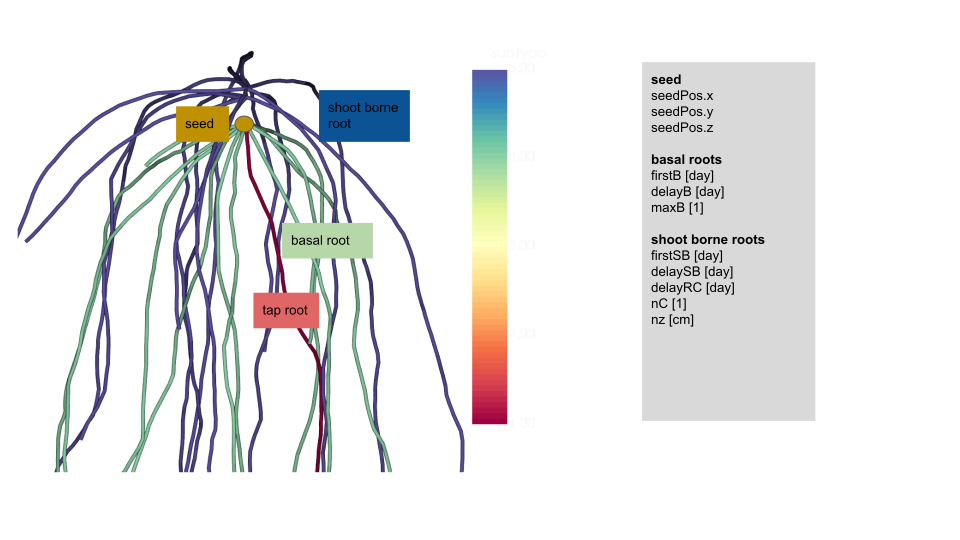

In [9]:
display(SVG(filename='figures/seed_params.svg'))

Some notes on Plant.initialize():

In [10]:
# calling initialize will reset the simulation
rs.initialize(True) # verbose = True # will call initializeLB(verbose)
rs.initializeLB(True) # verbose = True # apical zone is length based
rs.initializeDB(True) # verbose = True # apical zone is delay based

# rs.simulate(30) # [days]
# _ = vp.plot_roots(rs, "age", interactiveImage = False) # Plot, using vtk (e.g. "subType")

Access parameters:

In [11]:
print("Apical length of root subType", random_parameters[1].subType,"is", random_parameters[1].la, "cm")
random_parameters[1].la = 10
for p in random_parameters[1:]:
    print("Maximal root length for subType", p.subType, "is", p.lmax, "cm", "sd", p.lmaxs)

Apical length of root subType 1 is 2.2290001 cm
Maximal root length for subType 1 is 150.0 cm sd 0.0
Maximal root length for subType 2 is 2.29054 cm sd 1.80924
Maximal root length for subType 3 is 0.94 cm sd 0.0
Maximal root length for subType 4 is 150.0 cm sd 0.0


For root parameters subType 1 is always the tap root. SubType 2 and subType 3 refer to first and second order laterals. The occurance of basal or shootborne roots is defined within the seed parameters, and then are referred to as subType 4 , and subType 5. 

Change parameters, e.g. make the root system smaller

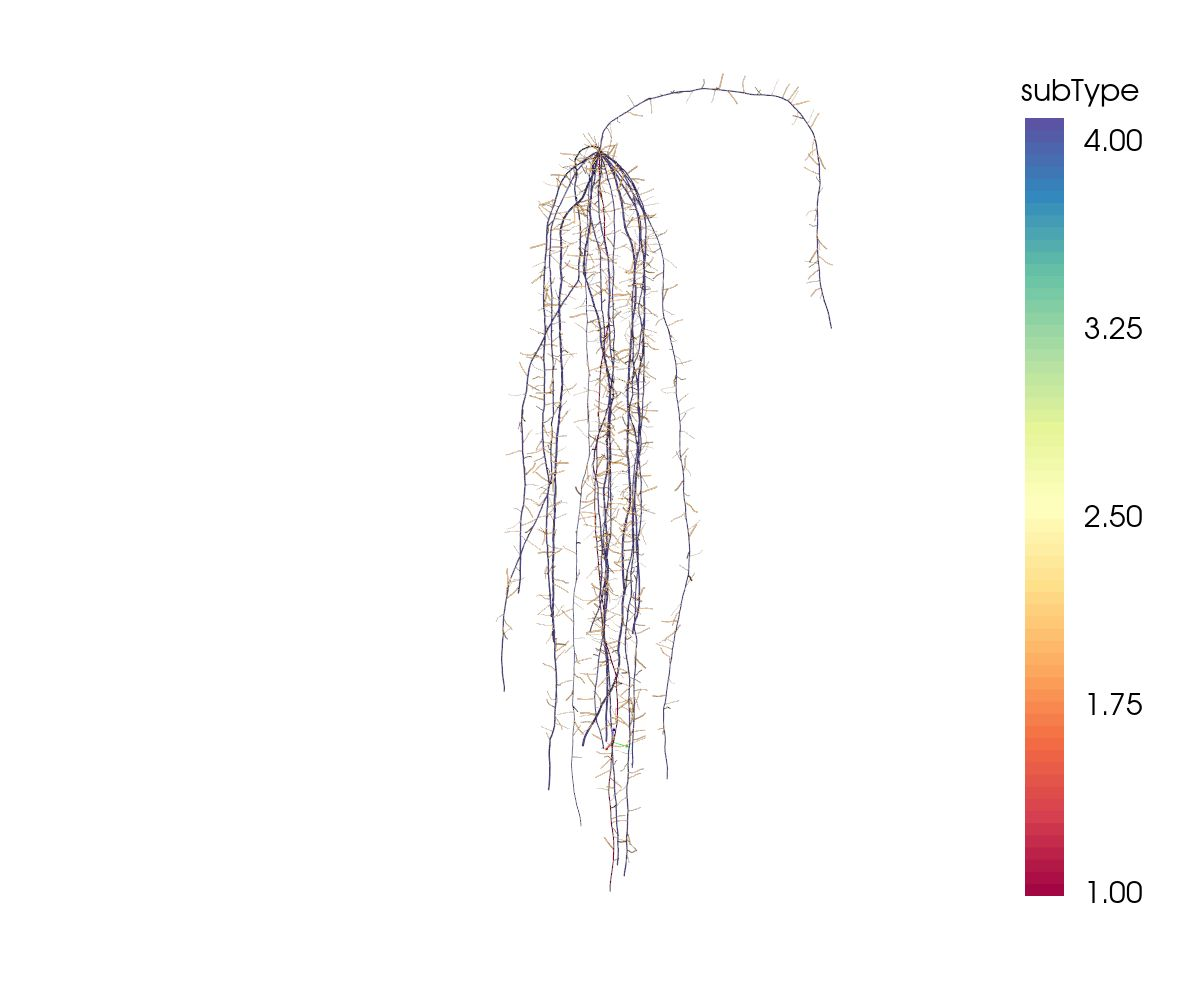

In [12]:
rs = pb.Plant()
rs.readParameters(path + name + ".xml")
random_parameters = rs.getOrganRandomParameter(pb.root)
random_parameters[2].lb = 0.
random_parameters[2].lbs = 0.
random_parameters[2].ln = 0.
random_parameters[2].lns = 0.
random_parameters[2].la = 0.
random_parameters[2].las = 0.
random_parameters[2].lmax = 1  # subType 2 are the first order laterals
random_parameters[2].lmaxs = 0  # cm
rs.initialize() 
rs.simulate(30) 
_  = vp.plot_roots(rs, "subType", interactiveImage = False) # Plot, using vtk 

The modified parameter set can be saved as xml parameter file. XML files can be conveniently viewed in a web browser. 

In [13]:
rs.writeParameters("modified_"+name + ".xml")

Specific root parameters can be accessed in similar way, but they should not be changed (since it is a simulation result). For postprocessing parameters can be obtained by using the organs *getParameter* function.

You do not need any parameter file, everything can be defined in the Python script from scratch:

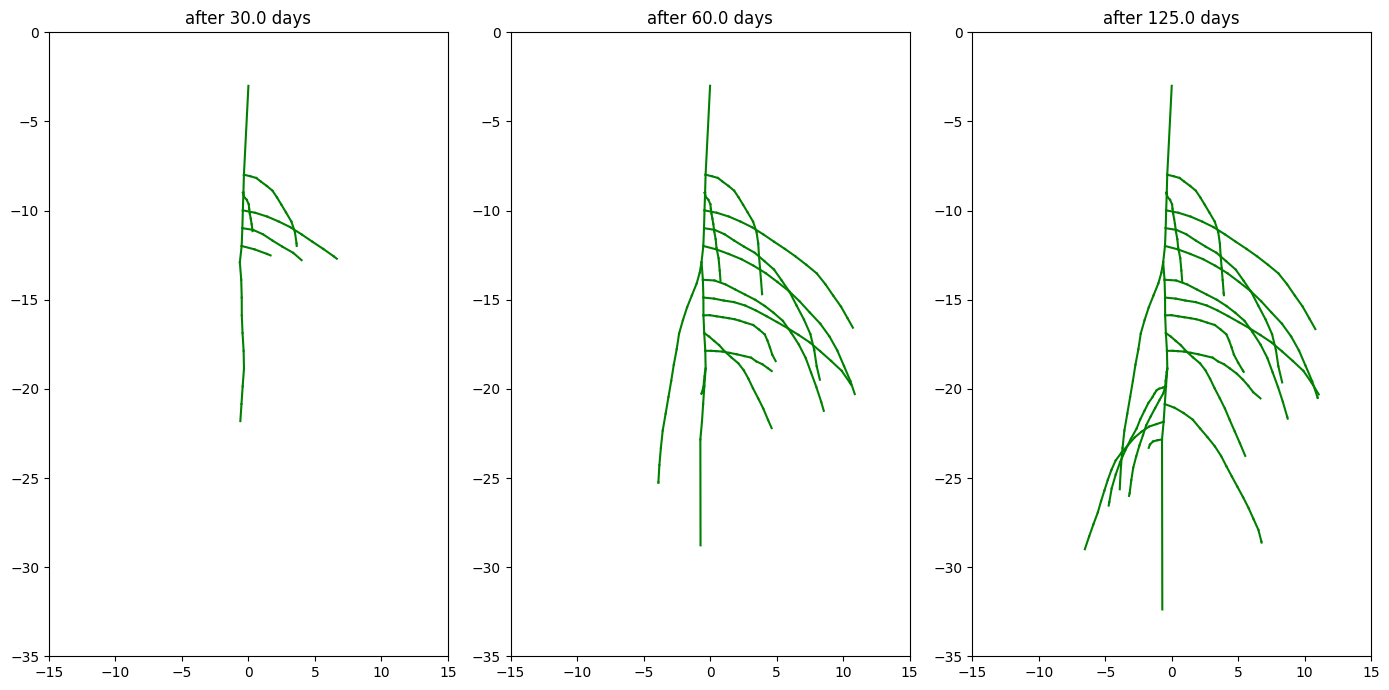

 length [29.53488439202972, 15.151330371493513, 14.943132311859586, 14.90542913331789, 14.994302945532825, 15.019966434757372, 15.395208451849559, 15.118191919981916, 14.89483255272804, 15.134270795051412, 14.991983222855659, 14.970608465955953, 15.201439260858685, 15.249112675797809, 15.092457446276951, 14.966058473614373, 3.760614263691009]
    age [125.0, 105.18927926789135, 103.1885380329312, 101.04476911346686, 98.73593787938299, 96.23448961121147, 93.50533626503966, 90.50283250833019, 87.16606345502346, 83.41116916640328, 79.11814385718309, 74.1065213172881, 68.08640045342356, 60.5469676049964, 50.452800506360006, 35.1280317933803, 2.1696631333370746]
subType [1.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0]
     la [10.0, 15.1513445037317, 14.943147325305326, 14.905448414678164, 14.994331545748476, 15.02000731799848, 15.395290090835733, 15.118287387436219, 14.894955582696797, 15.134517908842053, 14.992374181051568, 14.971359820771399, 15.20339

In [14]:
plant = pb.Plant()
p0 = pb.RootRandomParameter(plant)  # with default values,
p1 = pb.RootRandomParameter(plant)  # all standard deviations are 0

p0.name = "taproot"
p0.a = 0.2  # [cm] radius
p0.subType = 1  # [-] index starts at 1
p0.lb = 5  # [cm] basal zone
p0.la = 10  # [cm] apical zone
p0.lmax = 30  # [cm] maximal root length, number of lateral branching nodes = round((lmax-lb-la)/ln) + 1
p0.ln = 1.  # [cm] inter-lateral distance (16 branching nodes)
p0.theta = 0.  # [rad]
p0.r = 1  # [cm/day] initial growth rate
p0.dx = 10  # [cm] axial resolution
p0.successor = [[2]]  # add successors
p0.successorP = [[1]]  # probability that successor emerges
p0.tropismT = pb.TropismType.gravi  #
p0.tropismN = 1.8  # [-] strength of tropism
p0.tropismS = 0.2  # [rad/cm] maximal bending

p1.name = "lateral"
p1.a = 0.1  # [cm] radius
p1.subType = 2  # [1] index starts at 1
p1.lmax = 15  # # [cm] apical zone
p1.lmaxs = 0.15  # [cm] standard deviation of the apical zone
p1.theta = 90. / 180.*np.pi  # [rad]
p1.r = 2  # initial growth rate
p1.dx = 1  # [cm] axial resolution
p1.tropismT = pb.TropismType.gravi  # exo
p1.tropismN = 2  # [-] strength of tropism
p1.tropismS = 0.1  # [rad/cm] maximal bending

plant.setOrganRandomParameter(p0)
plant.setOrganRandomParameter(p1)

srp = pb.SeedRandomParameter(plant)  # with default values
srp.seedPos = pb.Vector3d(0., 0., -3.)  # [cm] seed position
srp.maxB = 0  # [-] number of basal roots (neglecting basal roots and shoot borne)
srp.firstB = 10.  # [day] first emergence of a basal root
srp.delayB = 3.  # [day] delay between the emergence of basal roots
plant.setOrganRandomParameter(srp)

plant.initialize()

fig, axes = plt.subplots(1, 3, figsize = (14, 7))
simtimes = [0, 30, 60, 125]  # the last lateral will emerge at
for i in range(0, 3):

    plant.simulate(np.diff(simtimes)[i])  #  [day]
    a = axes[i]
    a.set_xlim([-15, 15.])
    a.set_ylim([-35., 0.])  # starts at -3 cm, max lengthsimple root system from scratch (without parameter files) 30 cm
    a.set_title("after {} days".format(plant.getSimTime()))
    roots = plant.getPolylines()
    for root in roots:
        for j, n in enumerate(root[:-1]):
            n2 = root[j + 1]
            a.plot([n.x, n2.x], [n.z, n2.z], "g")

fig.tight_layout()
plt.show()

plant.write("/results/topics_parameters2.vtp")

# Some outputs.... (for each organ, i.e. root)
print(" length", plant.getParameter("length"))
print("    age", plant.getParameter("age"))
print("subType", plant.getParameter("subType"))
print("     la", plant.getParameter("la"))
print("la_mean", plant.getParameter("la_mean"))
print(" radius", plant.getParameter("radius"))

### 3. Using confining containers or obstacles
Confining geometry and obstacles can be defined using signed distance functions (SDF), classes are defined in *src/sdf.h*. 

Its always a good idea to define the soil volume (even if unconstrained), because otherwise roots may grow upwards out of the soil (which is normally not to be expected)!

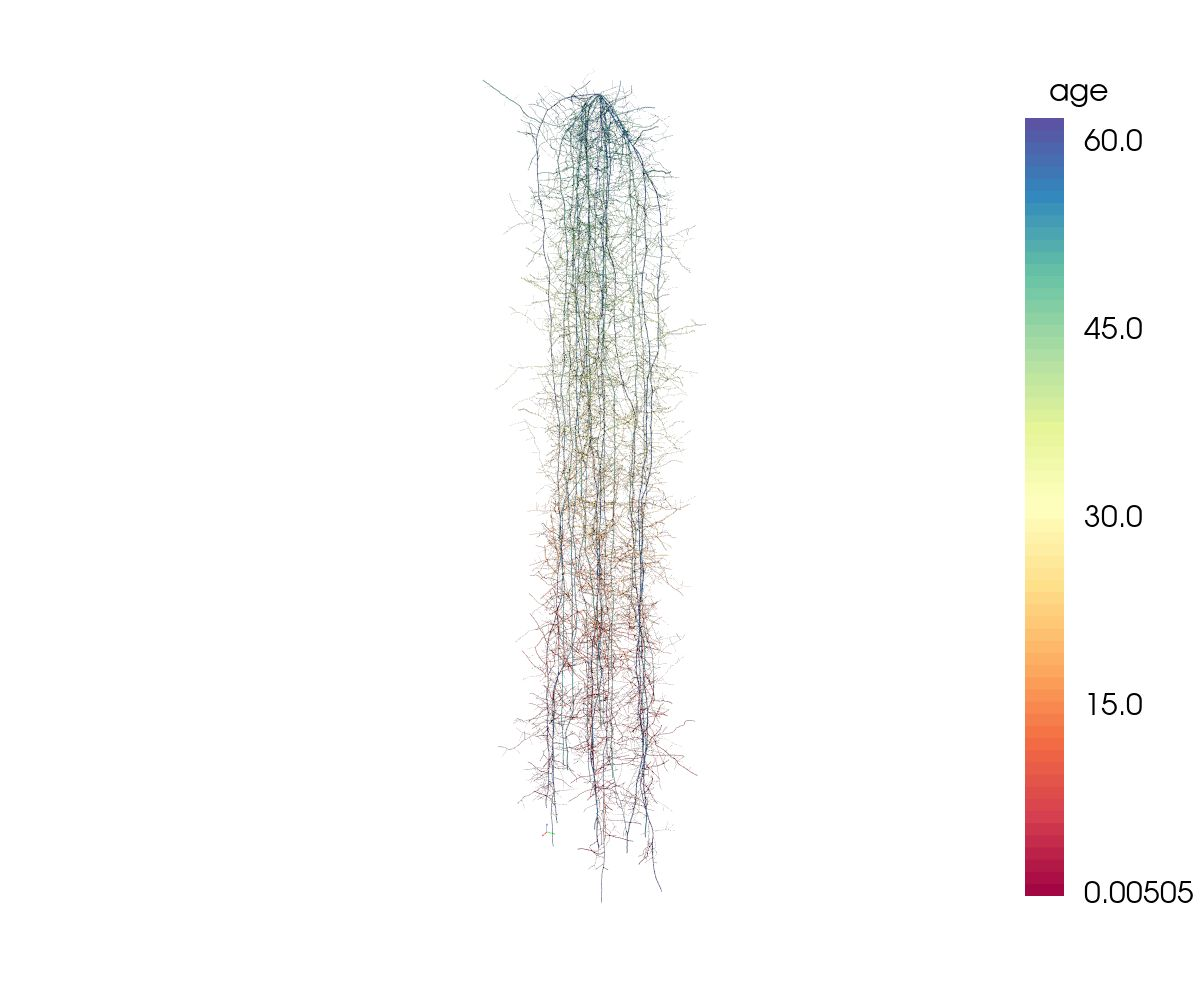

In [15]:
rs = pb.Plant()
rs.readParameters(path + name + ".xml")
rs.setGeometry(pb.SDF_PlantBox(1.e6,1.e6,1.e6)) # length, width, height [-5.e5,5.e5] [-5.e5,5.e5] [0.,-1.e6]
rs.initialize()
rs.simulate(60)  # days
_ = vp.plot_roots(rs, "age", interactiveImage = False) 

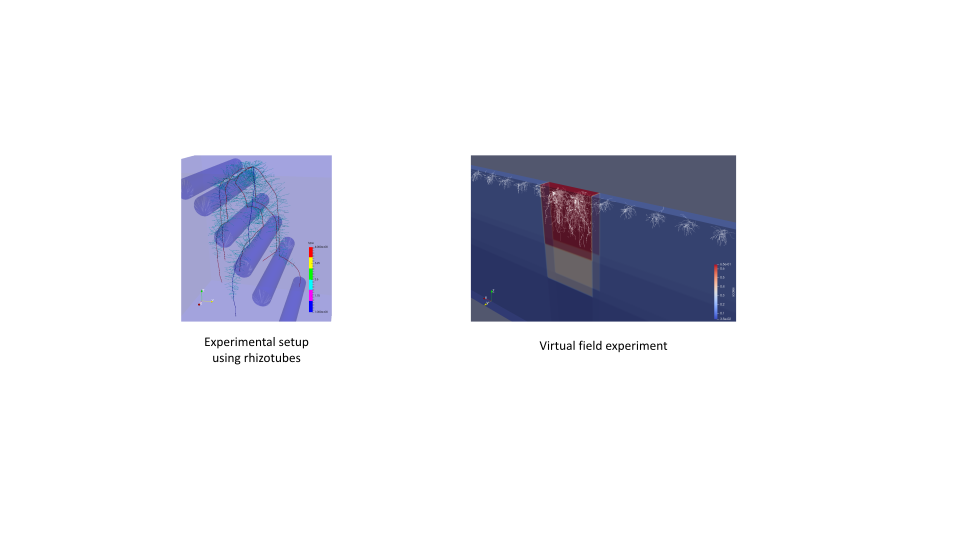

In [16]:
display(SVG(filename='figures/geometry.svg'))

Above graphs show virtual representations of actual field experiments. On the left we see a rhizotube set up, where horizontal tubes for observations with mini rhizotron cameras are located within the soil and act as obstacle to the roots. On the right we specify the red domain, using signed distance functions, to have different soil bulk density resulting in different root elongation rates. 

In the following we describe a split box experiment:

In [17]:
topBox = pb.SDF_PlantBox(22, 20, 5) # length, width, height [cm]
sideBox = pb.SDF_PlantBox(10, 20, 35)
left = pb.SDF_RotateTranslate(sideBox, pb.Vector3d(-6, 0, -5))
right = pb.SDF_RotateTranslate(sideBox, pb.Vector3d(6, 0, -5))
box_ = [topBox, left, right]
splitBox = pb.SDF_Union(box_)
print("distance to next boundary", topBox.getDist(pb.Vector3d(0, 0, -3)), "cm")

distance to next boundary -2.0 cm


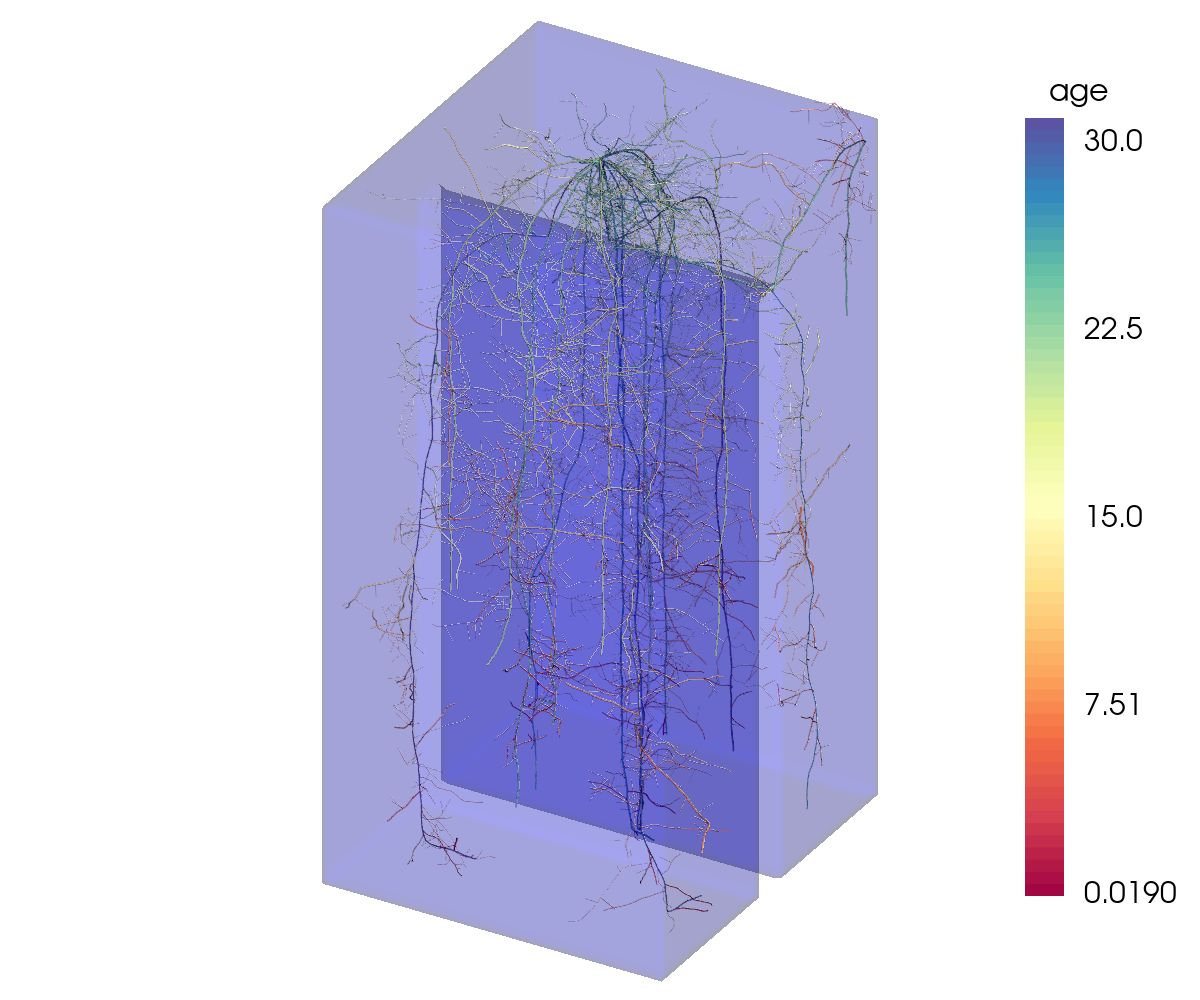

In [18]:
rs.setGeometry(splitBox)
rs.initialize()
rs.simulate(30)  # days
rs.write("splitbox.vtp")
_ = vp.plot_roots_and_container(rs, splitBox, "age", interactive = False) 

The implemented functions can be found in src/sdf.h, and src/sdf.cpp. Set operations can be used on SDF. In this way obstacles are implemented, e.g. pb.SDF_Difference(soil_geom, obstacle_geom).

## 4. Basic root system traits and their dynamics

To analyse root traits dynamically we need to create a simulation loop.

A typical simulation loop will look like

In [19]:
rs = pb.Plant()
path = "../../../modelparameter/structural/rootsystem/"
name = "Zea_mays_1_Leitner_2010"
rs.readParameters(path + name + ".xml")
rs.setGeometry(pb.SDF_PlantBox(1.e6,1.e6,1.e6)) 
rs.initialize(False)

""" Simulation loop """
simtime = 60.  # final simulation time [day]
dt = 1. # time step [day]
N = round(simtime / dt)  # number of iterations

for i in range(0, N):
    
    # Coupling to plant functional models or soil     
    
    rs.simulate(dt)
    
    # Coupling to plant functional models or soil 
    
    # Code for post-processing per time step (e.g. store relevant information in a list)
    

# Code for post-processing of the final result (write relevant results, e.g. csv, xls, etc.)
# _  = vp.plot_roots(rs, "subType", interactiveImage = False) # Plot, using vtk

### Analyse results from the class *Plant* directly (values per root) in a loop

The following example will plot length versus time for the root system, and each subType:

Seed::initialize: RootSystem 
writing VTP... first_example.vtp
writing RSML... first_example.rsml
Seed::initialize: RootSystem 
Seed::initialize: RootSystem 
Seed::initialize: RootSystem 
Seed::initialize: RootSystem 
Seed::initialize: RootSystem 
writing VTP... /results/topics_parameters2.vtp
Seed::initialize: RootSystem 
Seed::initialize: RootSystem 
writing VTP... splitbox.vtp
Seed::initialize: RootSystem 
Seed::initialize: Basal root type #4 was not defined, using tap root parameters instead


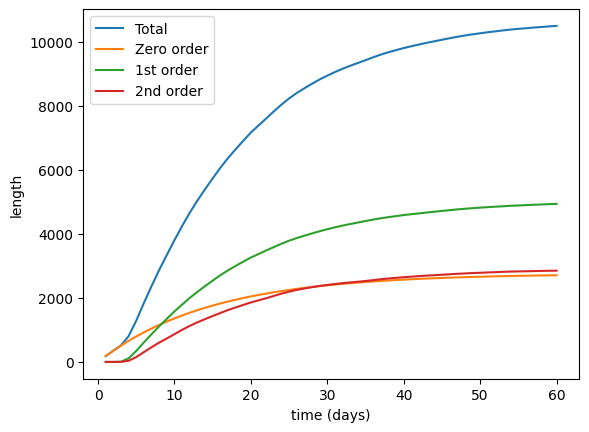

In [20]:
rs.initialize() # reset above simulation
scalar_type = "length" # "surface", "volume"
v_, v0_, v1_, v2_ = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)

""" Simulation loop """
for i in range(0, N):
    rs.simulate(dt)
    t = np.array(rs.getParameter("subType")) # value per root
    v = np.array(rs.getParameter(scalar_type)) # all random or specific parameters are accessible
    v_[i] = np.sum(v)
    v0_[i] = np.sum(v[t == 1]) + np.sum(v[t == 4])
    v1_[i] = np.sum(v[t == 2])
    v2_[i] = np.sum(v[t == 3])
    
t_ = np.linspace(dt, N * dt, N)
plt.plot(t_, v_, t_, v0_, t_, v1_, t_, v2_)
plt.xlabel("time (days)")
plt.ylabel(scalar_type)
plt.legend(["Total", "Zero order", "1st order", "2nd order"])
# plt.savefig("myplot.png") # we could save it as png
plt.show()

The following code will plot histogram for root radii classes of the final simulation result:

Seed::initialize: RootSystem 
Seed::initialize: Basal root type #4 was not defined, using tap root parameters instead
Total length 10656.903656600189 cm


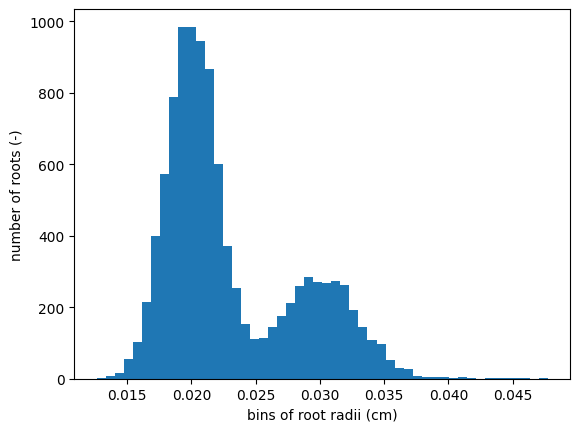

In [21]:
# Simulation
rs.initialize() # reset
rs.simulate(simtime)

# Post processing
print("Total length", np.sum(rs.getParameter("length")), "cm")

a = rs.getParameter("radius")
_ = plt.hist(a, bins='auto')
_ = plt.xlabel("bins of root radii (cm)")
_ = plt.ylabel("number of roots (-)")

# vp.plot_roots(rs, "subType") # Plot, using vtk 

Further interesting scalar traits that describe the extension of the root system are:

In [22]:
from scipy.spatial import ConvexHull

nodes_ = rs.getNodes()
nodes = np.array([[n.x, n.y, n.z] for n in nodes_])

rooting_depth = np.min(nodes[:,2])
horizontal_width = 2*np.max(np.sqrt(np.square(nodes[:,0])+np.square(nodes[:,1])))
convex_hull_volume = ConvexHull(nodes).volume

print("Rooting depth",rooting_depth, "cm")
print("Maximum width",horizontal_width, "cm")
print("Volume of the convex hull",convex_hull_volume, "cm^3")

Rooting depth -90.16098949321845 cm
Maximum width 22.149206400696496 cm
Volume of the convex hull 17171.904785831008 cm^3


### Analyse results using the class *SegmentAnalyser* (values per segment) 

The main functionality of the *SegmentAnalyser* class is:
* *getParameter(name)* as for *RootSystem* class, but returning a value for each segment, especially the "creationTime" of each segment
* *filter(name, min, max)* will keep only segments where the value of parameter *name* is within [min, max]
* *crop(sdf)* will keep only segments inside a geometry (e.g. in a soil core), segments intersecting the domain boundary are cut. 
* *distribution(...)* will create a 1d plot versus depth, where parameters are summed in layers 
* *distribution2d(...)* as above but 2d
* *mapPeriodic(length, width)* maps the unconstrained root system into a periodic domain
* *addData(name, data)* attach user data to the segments (e.g. simulation results for visualization or export)

Note that *SegmentAnalyser* is only loosly connected to the original simulation.

The first example shows how to obtain a depth distribution (values per segment) in a simulation loop.

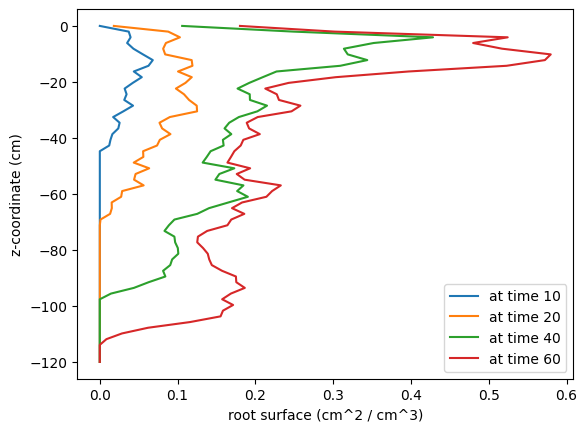

In [23]:
rs = pb.Plant()
path = "../../../modelparameter/structural/rootsystem/"
name = "Moraesetal_2018"
rs.readParameters(path + name + ".xml")
rs.setGeometry(pb.SDF_PlantBox(1.e6,1.e6,1.e6)) 
rs.initialize()

simtimes = [0,10,20,40,60] # day
dt_ = np.diff(simtimes) # day
depth = 120 # cm
layers = 60 # [1]

""" Simulation loop """
rsd_ = []
for dt in dt_:    
    rs.simulate(dt)
    # _ = vp.plot_roots(rs, "subType") # to observe growth
    ana = pb.SegmentAnalyser(rs) # create a SegmentAnalyser object
    rsd = ana.distribution("surface", 0., -depth, layers, True)
    rsd_.append(rsd) # store relevant data in a list

""" vizualize rld_ """
soilvolume = (depth / layers) * 10 * 10
rsd_ = np.array(rsd_) / soilvolume  # convert to density [cm2/cm3]

z_ = np.linspace(0, -depth, layers)  # z - axis
for i, t in enumerate(simtimes[1:]):
    plt.plot(rsd_[i,:], z_, label = "at time "+str(t))

plt.xlabel("root surface (cm^2 / cm^3)")
plt.ylabel("z-coordinate (cm)")
plt.legend()
# plt.savefig("surface_density.png")
plt.show()
# _ = vp.plot_roots(rs, "subType") # final result

Since the creation time (*creationTime*) of the segments is known, it is often sufficient to use pure post-processing when using the *SegmentAnalyser* class instead of loops. The following example shows the use of *mapPeriodic*, *filter()* and *crop()*.

The following code maps the root structure into a periodic domain. This approach is often used to mimic field conditions where the domain width is the inter-row distance and height is the inter-plant distance.

Unconstrained:
Minimum of bounding box ( -23.447, -20.6063, -111.824 )
Maximum of bounding box ( 22.8098, 27.7389, -0.000470352 )

Periodic domain:
Minimum of bounding box ( -10, -5, -111.824 )
Maximum of bounding box ( 10, 5, -0.000470352 )


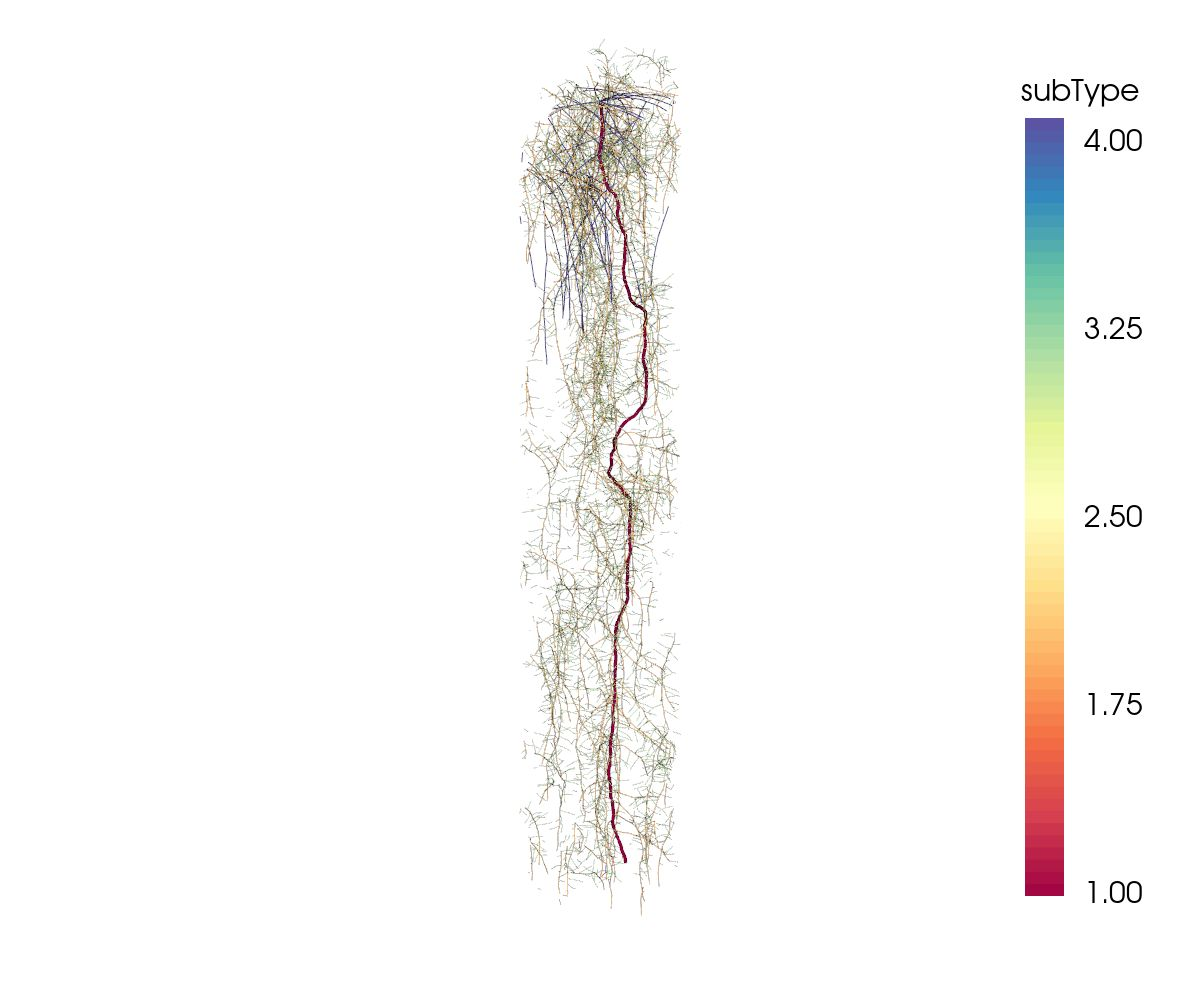

In [24]:
ana = pb.SegmentAnalyser(rs)
print("Unconstrained:")
print("Minimum of bounding box", ana.getMinBounds())
print("Maximum of bounding box", ana.getMaxBounds())
ana.mapPeriodic(20,10) # period in x and y direction [cm]
print("\nPeriodic domain:")
print("Minimum of bounding box", ana.getMinBounds())
print("Maximum of bounding box", ana.getMaxBounds())
_ = vp.plot_roots(ana, "subType", interactiveImage = False) # plots the periodic root system

Next we show a virtual coring experiment on the periodic domain (of size inter-row times inter-plant distance). We define one core on top of the plant, and one that is shifted by 10 cm. We compare the root surface density profiles obtained from both soil cores to the mean root surface density of each periodic soil layer.

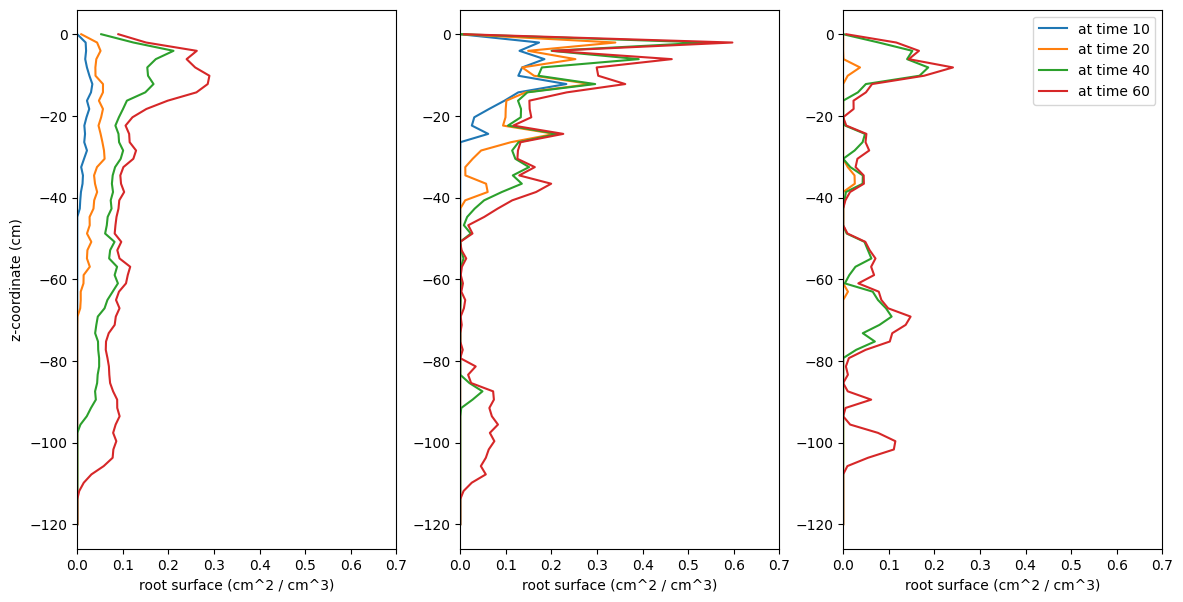

In [27]:
r, depth, layers = 2., 120., 60  # Soil core analysis
soilcore1 = pb.SDF_PlantContainer(r, r, depth, False)  # True = cubid, False = cylindric
soilcore2 = pb.SDF_RotateTranslate(soilcore1, 0, 0, pb.Vector3d(10., 0, 0))  # shift for 4 cm in x-direction

simtimes =  [0,10,20,40,60] # day
rsd_, rsd1_, rsd2_ = [], [], []
for t in simtimes[1:]:
    a = pb.SegmentAnalyser(ana) # copy 
    a.filter("creationTime", 0, t) # keep segments with creation time in [0, time]
    rsd = a.distribution("surface", 0., -depth, layers, True)
    rsd_.append(rsd) # all
    a2 = pb.SegmentAnalyser(a)
    a2.crop(soilcore1)
    rsd1 = a2.distribution("surface", 0., -depth, layers, True)
    rsd1_.append(rsd1) 
    a2 = pb.SegmentAnalyser(a)
    a2.crop(soilcore2)
    rsd2 = a2.distribution("surface", 0., -depth, layers, True)
    rsd2_.append(rsd2)

""" vizualize rsd_ """
soilvolume = (depth / layers) *r*r*np.pi
rsd_ = np.array(rsd_) / (20*10*(depth / layers))  # convert to density [cm2/cm3]
rsd1_ = np.array(rsd1_) / soilvolume  # convert to density [cm2/cm3]
rsd2_ = np.array(rsd2_) / soilvolume  # convert to density [cm2/cm3]

fig, ax = plt.subplots(1, 3, figsize=(14, 7))
z_ = np.linspace(0, -depth, layers)  # z - axis
for i, t in enumerate(simtimes[1:]):
    ax[0].plot(rsd_[i,:], z_, label = "at time "+str(t))
    ax[1].plot(rsd1_[i,:], z_, label = "at time "+str(t))
    ax[2].plot(rsd2_[i,:], z_, label = "at time "+str(t))
    
for a in ax:
    a.set_xlabel("root surface (cm^2 / cm^3)")
    a.set_xlim([0,.7])
ax[0].set_ylabel("z-coordinate (cm)")

plt.legend()
# plt.savefig("surface_density.png")
plt.show()